<a href="https://colab.research.google.com/github/LeinMS/hse-image-captioning/blob/BLIP/BLIP_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from PIL import Image
from transformers import AutoModelForVision2Seq, AutoProcessor
import time
import torch
import torch.nn as nn

In [2]:
#GET WEGHTS FROM MY GOOGLE.DRIVE
try:
    import gdown
except ImportError:
    %pip install gdown -q

file_id = "1-XRCk-B9GT9jglClA0NHoVuk3uzarRvt"
output_filename = "Flickr30k_1.zip"

print(f"Downloading file with ID {output_filename}...")
# Download the file using gdown
!gdown --id {file_id} -O {output_filename}

print(f"Unzipping {output_filename}...")
# Unzip the downloaded file
!unzip -o -q {output_filename}
print("Download and unzipping complete.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1-XRCk-B9GT9jglClA0NHoVuk3uzarRvt
From (redirected): https://drive.google.com/uc?id=1-XRCk-B9GT9jglClA0NHoVuk3uzarRvt&confirm=t&uuid=1b654b39-2ed8-42fa-b3aa-0ec475b13fbc
To: /content/Flickr30k_1.zip
100% 40.5M/40.5M [00:01<00:00, 33.8MB/s]
Unzipping Flickr30k_1.zip...
Download and unzipping complete.


In [42]:
#DEFINE MODEL
model_id = "Salesforce/blip-image-captioning-base"
processor = AutoProcessor.from_pretrained(model_id, torch_dtype=torch.float16)
model = AutoModelForVision2Seq.from_pretrained(model_id)
model.eval()

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

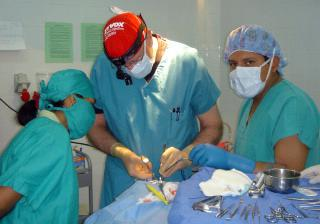

Inference time: 2.80
['a group of surgeons']


In [54]:
#INFERENCE OF ORIGINAL MODEL
import requests
img_url = 'https://datasets-server.huggingface.co/cached-assets/nlphuji/flickr30k/--/2b239befc81b6e3f035ce6bd52f5f4d60f5625f7/--/TEST/test/193/image/image.jpg?Expires=1766827544&Signature=bZS9tsW3SdYUBB-Q7i0Dn9OY0bExDAoFT0OZd2FczpTF4NPm65lNLUY3YwoO4UOiDtZ8fedHZ1eiW9-5vmdo23gtwFMgT3JneBjRf8wTJfxU2Qg9r5sh2vJcxXivOe5yIWFsFsBesqZ9N8DMp7RWBzECj65M3j-Pdm5tQkEm7Me0UOB4V-xyvs86gqoU2Q~5vo41D7EPq-PCmic6lUoT1rUwfN4hLvS7RVrmQdFv2JWJbNakLITvtvCpTDRcLoC-lbtd937wVljJ-gNkDX0AhzyFGg7HsyU9~26xwNrkE6oMlhUDrochkAc1R~wIhF0pNjY7k~a~oO70wFPcj46wHA__&Key-Pair-Id=K3EI6M078Z3AC3'
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

time_start = time.time()
processed = processor(images=image, padding="max_length", return_tensors="pt")
generated_output = model.generate(pixel_values=processed['pixel_values'], max_new_tokens=64)


x, y = image.size
scale = 1 if ((x <= 500) & (y <= 500)) else (x // 500 if x > y else y // 500)
display(image.resize((x//scale, y//scale)))

print(f'Inference time: {time.time() - time_start:.2f}')
print(processor.batch_decode(generated_output, skip_special_tokens=True))


In [44]:
#DEFINE FINETUNED MODEL
tuned_model = AutoModelForVision2Seq.from_pretrained('/content/Flickr30k_1')

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


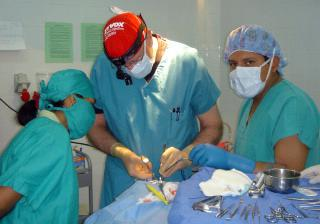

Inference time: 3.67
['a group of surgeons are performing a surgery in a hospital']


In [56]:
#INFERENCE OF FINETUNED MODEL
import requests
img_url = 'https://datasets-server.huggingface.co/cached-assets/nlphuji/flickr30k/--/2b239befc81b6e3f035ce6bd52f5f4d60f5625f7/--/TEST/test/193/image/image.jpg?Expires=1766827544&Signature=bZS9tsW3SdYUBB-Q7i0Dn9OY0bExDAoFT0OZd2FczpTF4NPm65lNLUY3YwoO4UOiDtZ8fedHZ1eiW9-5vmdo23gtwFMgT3JneBjRf8wTJfxU2Qg9r5sh2vJcxXivOe5yIWFsFsBesqZ9N8DMp7RWBzECj65M3j-Pdm5tQkEm7Me0UOB4V-xyvs86gqoU2Q~5vo41D7EPq-PCmic6lUoT1rUwfN4hLvS7RVrmQdFv2JWJbNakLITvtvCpTDRcLoC-lbtd937wVljJ-gNkDX0AhzyFGg7HsyU9~26xwNrkE6oMlhUDrochkAc1R~wIhF0pNjY7k~a~oO70wFPcj46wHA__&Key-Pair-Id=K3EI6M078Z3AC3'
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

time_start = time.time()
processed = processor(images=image, padding="max_length", return_tensors="pt")
generated_output = tuned_model.generate(pixel_values=processed['pixel_values'], max_new_tokens=64)


x, y = image.size
scale = 1 if ((x <= 500) & (y <= 500)) else (x // 500 if x > y else y // 500)
display(image.resize((x//scale, y//scale)))

print(f'Inference time: {time.time() - time_start:.2f}')
print(processor.batch_decode(generated_output, skip_special_tokens=True))